<a href="https://colab.research.google.com/github/Dong2Yo/DATA3960_1252/blob/main/Lectures/Modern_Data_Workflow_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Cleaning & Transformation Notebook

This notebook demonstrates:

- Load raw dataset

- Data exploration

- Cleaning (duplicates, missing values)

- Standardizing categories

- Feature engineering

- Export analytics dataset

Students will learn the pipeline before loading data into Microsoft Power BI.

## Business Context

A real estate company in Lethbridge wants a dashboard to understand housing market trends.

**Questions**:

- How many houses sold?

- Which neighborhoods are most active?

- How does size affect price?

## Explore Raw Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("lethbridge_real_estate_pipeline_demo.csv")

df.head()

,sale_id,address,city,neighborhood,postal_code,sale_price,sale_date,property_type,bedrooms,bathrooms,sqft,year_built,latitude,longitude
0,10000,997 Heritage Cres W,Lethbridge,North Lethbridge,T1K4T5,331000.0,2023-06-07,House,4.0,1.5,2536.0,2022,49.710470,-112.827543
1,10001,901 Mayor Magrath Dr S,Lethbridge,Legacy Ridge,T1K3M5,347000.0,2022-04-25,house,4.0,3.0,1340.0,2010,49.715146,-112.815676
2,10002,134 Southgate Blvd S,Lethbridge,South Lethbridge,T1H0A1,436000.0,2024-01-15,Townhouse,5.0,3.5,1472.0,2000,49.679264,-112.832549
3,10003,368 Scenic Dr N,Lethbridge,Riverstone,T1K8E2,179000.0,2024-02-24,house,2.0,2.0,1727.0,2007,49.674690,-112.888809
4,10004,799 Southgate Blvd S,Lethbridge,Riverstone,T1K1N3,289000.0,2022-09-06,Townhouse,3.0,1.0,1400.0,2011,49.673131,-112.891194


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2376 entries, 0 to 2375
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        2376 non-null   int64  
 1   address        2376 non-null   object 
 2   city           2376 non-null   object 
 3   neighborhood   2376 non-null   object 
 4   postal_code    2376 non-null   object 
 5   sale_price     2376 non-null   float64
 6   sale_date      2376 non-null   object 
 7   property_type  2376 non-null   object 
 8   bedrooms       2335 non-null   float64
 9   bathrooms      2336 non-null   float64
 10  sqft           2336 non-null   float64
 11  year_built     2376 non-null   int64  
 12  latitude       2376 non-null   float64
 13  longitude      2376 non-null   float64
dtypes: float64(6), int64(2), object(6)
memory usage: 260.0+ KB


### Questions to consider:

- Which columns are numeric vs categorical?

- Are there missing values?

In [ ]:
df.shape

(2376, 14)

In [ ]:
df.describe()

,sale_id,sale_price,bedrooms,bathrooms,sqft,year_built,latitude,longitude
count,2376.000000,2376.000000,2335.000000,2336.000000,2336.000000,2376.000000,2376.000000,2376.000000
mean,11177.369949,358892.255892,3.500642,2.234161,1711.970462,2004.192340,49.687841,-112.851337
std,679.164604,94740.088591,0.960164,0.857868,515.232009,11.330278,0.018487,0.029125
min,10000.000000,120000.000000,2.000000,1.000000,801.000000,1985.000000,49.654871,-112.898419
25%,10591.750000,293750.000000,3.000000,1.500000,1263.750000,1994.000000,49.671937,-112.879241
50%,11176.500000,356000.000000,3.000000,2.000000,1708.000000,2004.000000,49.682094,-112.838593
75%,11764.250000,424000.000000,4.000000,3.000000,2162.250000,2014.000000,49.707037,-112.822974
max,12355.000000,675000.000000,5.000000,3.500000,2599.000000,2023.000000,49.720333,-112.806188


### Observing

- average sale price

- min/max property size

- bedroom distribution

In [ ]:
df.columns

Index(['sale_id', 'address', 'city', 'neighborhood', 'postal_code',
       'sale_price', 'sale_date', 'property_type', 'bedrooms', 'bathrooms',
       'sqft', 'year_built', 'latitude', 'longitude'],
      dtype='object')

In [ ]:
df['property_type'].value_counts()

property_type
house        619
Townhouse    612
Condo        577
House        568
Name: count, dtype: int64

### Categories are inconsistent (House vs house).

This motivates data cleaning.

In [ ]:
df['neighborhood'].value_counts()

neighborhood
South Lethbridge    422
North Lethbridge    421
Fairmont            415
Legacy Ridge        396
West Lethbridge     365
Riverstone          357
Name: count, dtype: int64

### This helps us understand geographic segmentation.

In [ ]:
df['sale_price'].describe()

count      2376.000000
mean     358892.255892
std       94740.088591
min      120000.000000
25%      293750.000000
50%      356000.000000
75%      424000.000000
max      675000.000000
Name: sale_price, dtype: float64

### Checking Price Distribution: average, median & max value

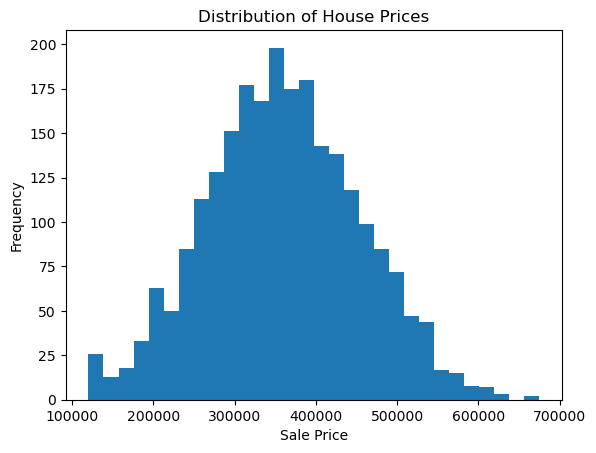

In [ ]:
plt.hist(df['sale_price'], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df['bedrooms'].value_counts().sort_index()

bedrooms
2.0    389
3.0    783
4.0    768
5.0    395
Name: count, dtype: int64

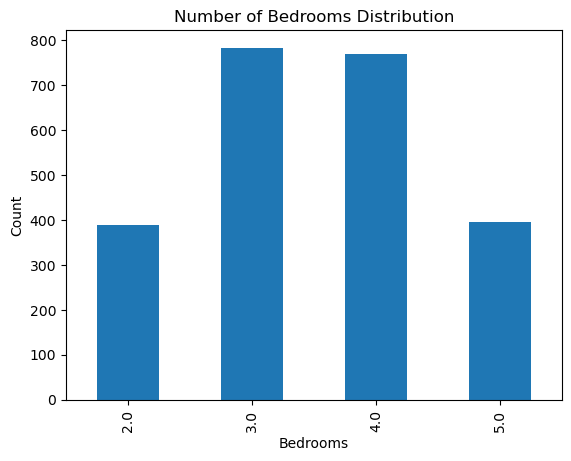

In [ ]:
df['bedrooms'].value_counts().sort_index().plot(kind='bar')

plt.title("Number of Bedrooms Distribution")
plt.xlabel("Bedrooms")
plt.ylabel("Count")

plt.show()

### Detecting outliers or skewed distributions.

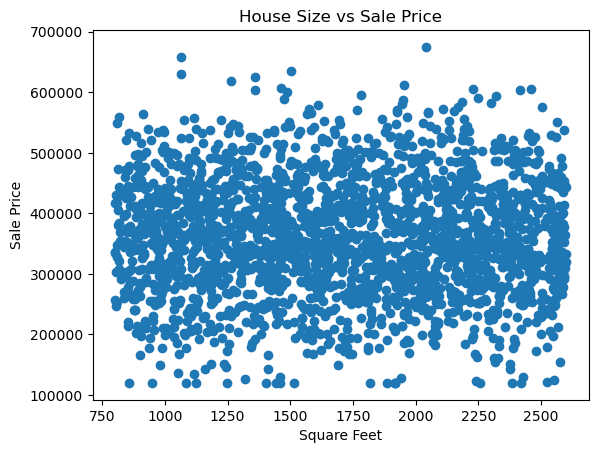

In [ ]:
plt.scatter(df['sqft'], df['sale_price'])

plt.title("House Size vs Sale Price")
plt.xlabel("Square Feet")
plt.ylabel("Sale Price")

plt.show()

### Exploring Relationship: Size vs Price

In [ ]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['sale_date'].head()

0   2023-06-07
1   2022-04-25
2   2024-01-15
3   2024-02-24
4   2022-09-06
Name: sale_date, dtype: datetime64[ns]

In [ ]:
df['sale_year'] = df['sale_date'].dt.year

df['sale_year'].value_counts()

sale_year
2024    841
2023    770
2022    765
Name: count, dtype: int64

### Exploring Trend: Sales Over Time

### Summary

**Before cleaning data or building dashboards, analysts must understand the structure, quality, and patterns in the raw data.**

Key steps:

>Inspect structure

>Identify missing values

>Check duplicates

>Explore distributions

>Identify inconsistencies

## Data Cleaning

In [ ]:
## Convert columns to correct formats.

# convert date
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

# numeric columns
numeric_cols = ['sale_price', 'bedrooms', 'bathrooms', 'sqft', 'year_built']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2376 entries, 0 to 2375
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_id        2376 non-null   int64         
 1   address        2376 non-null   object        
 2   city           2376 non-null   object        
 3   neighborhood   2376 non-null   object        
 4   postal_code    2376 non-null   object        
 5   sale_price     2376 non-null   float64       
 6   sale_date      2376 non-null   datetime64[ns]
 7   property_type  2376 non-null   object        
 8   bedrooms       2335 non-null   float64       
 9   bathrooms      2336 non-null   float64       
 10  sqft           2336 non-null   float64       
 11  year_built     2376 non-null   int64         
 12  latitude       2376 non-null   float64       
 13  longitude      2376 non-null   float64       
 14  sale_year      2376 non-null   int32         
dtypes: datetime64[ns](1),

### Checking

- duplicates

- missing values

- inconsistent categories

In [ ]:
df.duplicated().sum()

20

In [ ]:
df[df.duplicated()]

,sale_id,address,city,neighborhood,postal_code,sale_price,sale_date,property_type,bedrooms,bathrooms,sqft,year_built,latitude,longitude
2356,10672,999 Fairmont Blvd S,Lethbridge,Fairmont,T1K2R8,227000.0,2023-11-18,Condo,NaN,3.0,1548.0,2005,49.663448,-112.872555
2357,11185,958 Columbia Blvd W,Lethbridge,South Lethbridge,T1H0A1,431000.0,2023-06-03,Townhouse,3.0,3.5,1457.0,2013,49.677936,-112.836721
2358,11652,695 Whoop Up Dr W,Lethbridge,North Lethbridge,T1K2R8,265000.0,2022-10-24,Condo,4.0,3.0,2174.0,2020,49.706090,-112.819781
2359,10611,617 Riverstone Blvd W,Lethbridge,Legacy Ridge,T1K3M4,384000.0,2024-07-31,Condo,5.0,3.5,2581.0,1999,49.713807,-112.815797
2360,10179,536 Fairmont Blvd S,Lethbridge,North Lethbridge,T1H5L7,214000.0,2023-03-16,House,4.0,1.0,1946.0,2018,49.706541,-112.827443
2361,11927,400 Scenic Dr S,Lethbridge,Riverstone,T1K5A3,482000.0,2024-12-18,Townhouse,3.0,1.5,1766.0,2012,49.670771,-112.888257
2362,11561,168 Riverstone Blvd W,Lethbridge,North Lethbridge,T1K6Y1,386000.0,2023-11-22,House,4.0,1.0,2123.0,2021,49.703875,-112.825932
2363,11694,381 Riverstone Blvd W,Lethbridge,South Lethbridge,T1K1N3,315000.0,2023-10-19,Townhouse,2.0,3.5,2214.0,1998,49.674632,-112.836148
2364,10677,97 Southgate Blvd S,Lethbridge,West Lethbridge,T1H2S5,364000.0,2023-01-24,Condo,3.0,3.0,1209.0,2023,49.696456,-112.876499
2365,10831,86 Columbia Blvd W,Lethbridge,Fairmont,T1H5L7,342000.0,2024-07-30,House,5.0,1.5,2447.0,2007,49.658222,-112.871420


In [ ]:
# remove duplicates based on transaction id
df = df.drop_duplicates(subset='sale_id')

df.shape

(2356, 15)

In [ ]:
# standardize property type
df['property_type'] = df['property_type'].str.lower().str.strip()

# standardize neighborhood
df['neighborhood'] = df['neighborhood'].str.strip()

# check results
df['property_type'].value_counts()

property_type
house        1178
townhouse     608
condo         570
Name: count, dtype: int64

In [ ]:
##Checking missing value

df.isnull().sum()

sale_id           0
address           0
city              0
neighborhood      0
postal_code       0
sale_price        0
sale_date         0
property_type     0
bedrooms         40
bathrooms        40
sqft             40
year_built        0
latitude          0
longitude         0
sale_year         0
dtype: int64

### Discussing

Missing values are common in real datasets and must be handled before analysis.

In [ ]:
## Fill numeric missing values with median.

df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

df['sqft'] = df['sqft'].fillna(df['sqft'].median())

### Any other straties?

In [ ]:
## Checking for unrealistic values.

df[['sale_price','sqft','bedrooms','bathrooms']].describe()

,sale_price,sqft,bedrooms,bathrooms
count,2356.000000,2356.000000,2356.000000,2356.00000
mean,358982.173175,1712.280136,3.493633,2.22899
std,94759.992389,510.958463,0.954352,0.85043
min,120000.000000,801.000000,2.000000,1.00000
25%,293750.000000,1272.000000,3.000000,1.50000
50%,356000.000000,1708.500000,3.000000,2.00000
75%,424000.000000,2152.250000,4.000000,3.00000
max,675000.000000,2599.000000,5.000000,3.50000


In [ ]:
df = df[df['sale_price'] > 50000]
df = df[df['sqft'] > 300]

## Feature Engineering

In [ ]:
## Creating time features
# Ensure sale_date is datetime
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

# Create time features
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month
df['sale_quarter'] = df['sale_date'].dt.quarter

In [ ]:
df[['sale_date','sale_year','sale_month','sale_quarter']].head()

,sale_date,sale_year,sale_month,sale_quarter
0,2023-06-07,2023,6,2
1,2022-04-25,2022,4,2
2,2024-01-15,2024,1,1
3,2024-02-24,2024,2,1
4,2022-09-06,2022,9,3


In [ ]:
## Creating price per square foot

df['price_per_sqft'] = df['sale_price'] / df['sqft']

In [ ]:
## Creating property age
df['property_age'] = df['sale_year'] - df['year_built']

In [ ]:
## Price Segmentation

df['price_segment'] = pd.qcut(
    df['sale_price'],
    q=4,
    labels=['Low','Medium','High','Luxury']
)

In [ ]:
## Property Size Category

df['size_category'] = pd.cut(
    df['sqft'],
    bins=[0,1000,1600,2200,5000],
    labels=['Small','Medium','Large','Luxury']
)

In [ ]:
## Validating Engineered Features
df[['price_per_sqft','property_age']].describe()


,price_per_sqft,property_age
count,2356.000000,2356.000000
mean,232.316977,18.867572
std,102.135398,11.382123
min,47.939778,-1.000000
25%,156.247116,9.000000
50%,209.566014,19.000000
75%,287.100109,29.000000
max,685.434517,39.000000


In [ ]:
df['price_segment'].value_counts()



price_segment
Medium    594
High      590
Low       589
Luxury    583
Name: count, dtype: int64

In [ ]:
df['size_category'].value_counts()

size_category
Large     812
Medium    780
Luxury    530
Small     234
Name: count, dtype: int64

In [ ]:
## Selecting Columns for Pre-modelling Dataset

analytics_columns = [

'sale_id',
'city',
'neighborhood',
'sale_price',
'sale_date',
'sale_year',
'sale_month',
'property_type',
'bedrooms',
'bathrooms',
'sqft',
'price_per_sqft',
'property_age',
'price_segment',
'size_category',
'latitude',
'longitude'

]

analytics_df = df[analytics_columns]

In [ ]:
## Final Validation
analytics_df.head()



,sale_id,city,neighborhood,sale_price,sale_date,sale_year,sale_month,property_type,bedrooms,bathrooms,sqft,price_per_sqft,property_age,price_segment,size_category,latitude,longitude
0,10000,Lethbridge,North Lethbridge,331000.0,2023-06-07,2023,6,house,4.0,1.5,2536.0,130.520505,1,Medium,Luxury,49.710470,-112.827543
1,10001,Lethbridge,Legacy Ridge,347000.0,2022-04-25,2022,4,house,4.0,3.0,1340.0,258.955224,12,Medium,Medium,49.715146,-112.815676
2,10002,Lethbridge,South Lethbridge,436000.0,2024-01-15,2024,1,townhouse,5.0,3.5,1472.0,296.195652,24,Luxury,Medium,49.679264,-112.832549
3,10003,Lethbridge,Riverstone,179000.0,2024-02-24,2024,2,house,2.0,2.0,1727.0,103.647944,17,Low,Large,49.674690,-112.888809
4,10004,Lethbridge,Riverstone,289000.0,2022-09-06,2022,9,townhouse,3.0,1.0,1400.0,206.428571,11,Low,Medium,49.673131,-112.891194


In [ ]:
analytics_df.info()

analytics_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sale_id         2356 non-null   int64         
 1   city            2356 non-null   object        
 2   neighborhood    2356 non-null   object        
 3   sale_price      2356 non-null   float64       
 4   sale_date       2356 non-null   datetime64[ns]
 5   sale_year       2356 non-null   int32         
 6   sale_month      2356 non-null   int32         
 7   property_type   2356 non-null   object        
 8   bedrooms        2356 non-null   float64       
 9   bathrooms       2356 non-null   float64       
 10  sqft            2356 non-null   float64       
 11  price_per_sqft  2356 non-null   float64       
 12  property_age    2356 non-null   int64         
 13  price_segment   2356 non-null   category      
 14  size_category   2356 non-null   category      
 15  latitude 

,sale_id,sale_price,sale_date,sale_year,sale_month,bedrooms,bathrooms,sqft,price_per_sqft,property_age,latitude,longitude
count,2356.000000,2356.000000,2356,2356.000000,2356.000000,2356.000000,2356.00000,2356.000000,2356.000000,2356.000000,2356.000000,2356.000000
mean,11177.500000,358982.173175,2023-07-13 00:16:30.152801280,2023.030136,6.524194,3.493633,2.22899,1712.280136,232.316977,18.867572,49.687836,-112.851383
min,10000.000000,120000.000000,2022-01-01 00:00:00,2022.000000,1.000000,2.000000,1.00000,801.000000,47.939778,-1.000000,49.654871,-112.898419
25%,10588.750000,293750.000000,2022-10-05 18:00:00,2022.000000,3.000000,3.000000,1.50000,1272.000000,156.247116,9.000000,49.671957,-112.879279
50%,11177.500000,356000.000000,2023-07-20 12:00:00,2023.000000,7.000000,3.000000,2.00000,1708.500000,209.566014,19.000000,49.682094,-112.838632
75%,11766.250000,424000.000000,2024-04-13 00:00:00,2024.000000,9.000000,4.000000,3.00000,2152.250000,287.100109,29.000000,49.707061,-112.822978
max,12355.000000,675000.000000,2024-12-31 00:00:00,2024.000000,12.000000,5.000000,3.50000,2599.000000,685.434517,39.000000,49.720333,-112.806188
std,680.262939,94759.992389,NaN,0.821903,3.462362,0.954352,0.85043,510.958463,102.135398,11.382123,0.018470,0.029134


### Discussions on more advanced feature engineering:

>neighborhood price index

>market demand indicators

>rolling price trends

>time-to-sale estimation
>
>...


## Export Analytics Dataset

In [ ]:
analytics_df.to_csv(
    "lethbridge_real_estate_pipeline_pre-modelling.csv",
    index=False
)